In [2]:
import pandas as pd

path = r"D:\apprendre Tkinter\appli reglage param correct\numerique.xlsx"

df = pd.read_excel(path)  # path = chemin du fichier sélectionné
print(df.head())


   Tamis(mm)  Cumul(%)
0       22.4      12.6
1       31.5      10.0
2       40.0      23.5
3       50.0      20.0
4       60.0      32.0


In [7]:
df.iloc[:, 1].tolist()
print(df["Cumul(%)"].tolist())

[12.6, 10.0, 23.5, 20.0, 32.0, 2.9]


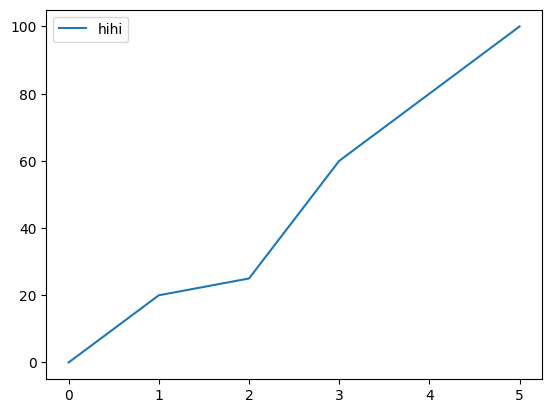

In [3]:
import matplotlib.pyplot as plt

plt.plot([0,1,2,3,5],[0,20,25,60,100],label="hihi")
plt.legend()

In [ ]:
import zipfile
import pandas as pd



with zipfile.ZipFile("donnees.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("data.csv")
    z.write("notes.txt")


In [1]:
import pandas as pd
data = [
    [22.4, 12.6],
    [31.5, 10.0],
    [40, 23.5],
    [50, 20.0],
    [60, 32.0],
]

colonnes = ["Tamis(mm)", "Cumul(%)"]

df = pd.DataFrame(data, columns=colonnes)

df.to_csv("personnes.csv", index=False)

print(df)

   Tamis(mm)  Cumul(%)
0       22.4      12.6
1       31.5      10.0
2       40.0      23.5
3       50.0      20.0
4       60.0      32.0


In [ ]:
lignes = [
    "scale = 23.0",
    "offset = 2.0"
]
with open("notes.txt", "w", encoding="utf-8") as f:
    for ligne in lignes:
        f.write(ligne + "\n")

In [26]:
import zipfile
import pandas as pd
from io import StringIO
data = [
    [22.4, 5.00],
    [31.5, 12.57],
    [40, 58.65],
    [50, 89.93],
    [60, 100],
    [80, 100]
]

colonnes = ["Tamis(mm)", "Cumul(%)"]

df = pd.DataFrame(data, columns=colonnes)
# On écrit le CSV dans un buffer en mémoire (pour éviter de créer un .csv qu'on ne va pas utiliser)
buffer_csv = StringIO()
df.to_csv(buffer_csv, index=False)

texte = "Scale = 0.32\nOffset = 22.86"

with zipfile.ZipFile("mesure.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.writestr("data.csv", buffer_csv.getvalue())
    z.writestr("params_correction.txt", texte)


In [19]:
import zipfile
import pandas as pd

# Ouvrir le ZIP
with zipfile.ZipFile("mesure.zip", "r") as z:
    
    # --- Lire le CSV directement dans un DataFrame ---
    with z.open("data.csv") as f:
        df = pd.read_csv(f)
    
    # --- Lire le TXT directement dans une variable ---
    with z.open("params_correction.txt") as f:
        texte = f.read().decode("utf-8")  # convertir les bytes en string

# Afficher les résultats
print("DataFrame CSV :\n", df)
print("\nContenu TXT :\n", texte)


DataFrame CSV :
    Tamis(mm)  Cumul(%)
0       22.4      12.6
1       31.5      10.0
2       40.0      23.5
3       50.0      20.0
4       60.0      32.0
5       80.0       2.9

Contenu TXT :
 Scale = 23.0
Offset = 2.0


In [20]:
variables = {}
for ligne in texte.splitlines():
    # ignorer les lignes vides
    if ligne.strip():
        # séparer par le '='
        nom, val = ligne.split("=")
        nom = nom.strip()        # enlever espaces autour du nom
        val = val.strip()        # enlever espaces autour de la valeur
        
        # convertir en float si possible
        try:
            val = float(val)
        except ValueError:
            pass  # garder en string si ce n'est pas un nombre
        
        variables[nom] = val

print(variables)

{'Scale': 23.0, 'Offset': 2.0}


In [23]:
l = df["Cumul(%)"].tolist()
print(l[1])

10.0


In [17]:
type(variables["Scale"])

float

In [9]:
import numpy as np
import copy
l1 = [1,2,3,4]
l2 = [5,6,7,8]
l3 = np.array([[elt1,elt2] for elt1, elt2 in zip(l1,l2)])
l4 = copy.deepcopy(l3)
print(l3-l4)


[[0 0]
 [0 0]
 [0 0]
 [0 0]]
